# Análisis exploratorio de los datos

## Librerías

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

In [36]:
df_train = pd.read_csv("../data/conjuntos/datos_entrenamiento.csv")
df_test = pd.read_csv("../data/conjuntos/datos_prueba.csv")

df = pd.concat([df_train, df_test], ignore_index=True)
print(f"Filas totales: {len(df)}")

Filas totales: 15580


## Análisis

Analizamos los estadísticos básicos

In [37]:
df.describe()

,Fase,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia,EnergiaActiva
count,15580.000000,15580.000000,15580.000000,15580.000000,15580.000000,15580.000000,15580.000000
mean,1.500000,117.838188,2.637078,267.837521,0.787994,59.957718,271.054958
std,0.500016,2.636585,1.904476,220.767556,0.129881,0.017227,163.925184
min,1.000000,106.830000,0.328000,19.080000,0.461000,59.900000,0.159000
25%,1.000000,116.070000,1.642000,126.910000,0.723000,59.950000,117.285000
50%,1.500000,118.070000,2.278500,223.570000,0.832000,59.960000,300.309500
75%,2.000000,119.810000,3.213000,330.380000,0.866000,59.970000,422.474000
max,2.000000,124.760000,17.272000,1932.830000,1.000000,60.000000,487.157000


Determinamos si existen valores atípicos

In [38]:
def detectar_atipicos_iqr(df, columnas=[], factor=1.5):
    """
    Detecta valores atípicos usando el método del rango intercuartílico (IQR).
    Retorna un resumen por columna y una máscara booleana por fila.
    """

    resumen = []

    for col in columnas:
        serie = df[col].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - factor * iqr
        limite_superior = q3 + factor * iqr

        mascara_col = (df[col] < limite_inferior) | (df[col] > limite_superior)
        n_atipicos = int(mascara_col.sum())
        pct_atipicos = (n_atipicos / len(df)) * 100 if len(df) else 0.0

        resumen.append({
            "columna": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "n_atipicos": n_atipicos,
            "pct_atipicos": round(pct_atipicos, 2),
        })

    resumen_df = pd.DataFrame(resumen).sort_values("n_atipicos", ascending=False).reset_index(drop=True)
    return resumen_df

In [39]:
columnas_analisis = ["Voltaje", "Corriente", "Potencia", "FactorPotencia", "Frecuencia", "EnergiaActiva"]

resumen_train = detectar_atipicos_iqr(df_train, columnas=columnas_analisis)
resumen_test = detectar_atipicos_iqr(df_test, columnas=columnas_analisis)
resumen_total = detectar_atipicos_iqr(df, columnas=columnas_analisis)

print("Atípicos en entrenamiento:")
display(resumen_train)

print("Atípicos en prueba:")
display(resumen_test)

print("Atípicos en dataset completo:")
display(resumen_total)

Atípicos en entrenamiento:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.6420,3.21300,1.57100,-0.714500,5.569500,575,7.38
1,Potencia,126.9175,330.37100,203.45350,-178.262750,635.551250,538,6.91
2,FactorPotencia,0.7230,0.86600,0.14300,0.508500,1.080500,497,6.38
3,Frecuencia,59.9500,59.97000,0.02000,59.920000,60.000000,283,3.63
4,Voltaje,116.0700,119.81000,3.74000,110.460000,125.420000,42,0.54
5,EnergiaActiva,117.2945,422.47225,305.17775,-340.472125,880.238875,0,0.00


Atípicos en prueba:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.6420,3.21300,1.57100,-0.714500,5.569500,575,7.38
1,Potencia,126.9175,330.37100,203.45350,-178.262750,635.551250,538,6.91
2,FactorPotencia,0.7230,0.86600,0.14300,0.508500,1.080500,497,6.38
3,Frecuencia,59.9500,59.97000,0.02000,59.920000,60.000000,283,3.63
4,Voltaje,116.0700,119.81000,3.74000,110.460000,125.420000,42,0.54
5,EnergiaActiva,117.2945,422.47225,305.17775,-340.472125,880.238875,0,0.00


Atípicos en dataset completo:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.642,3.213,1.571,-0.7145,5.5695,1150,7.38
1,Potencia,126.910,330.380,203.470,-178.2950,635.5850,1076,6.91
2,FactorPotencia,0.723,0.866,0.143,0.5085,1.0805,994,6.38
3,Frecuencia,59.950,59.970,0.020,59.9200,60.0000,566,3.63
4,Voltaje,116.070,119.810,3.740,110.4600,125.4200,84,0.54
5,EnergiaActiva,117.285,422.474,305.189,-340.4985,880.2575,0,0.00


Graficamos las dos series por separado

Gráficas de entrenamiento:


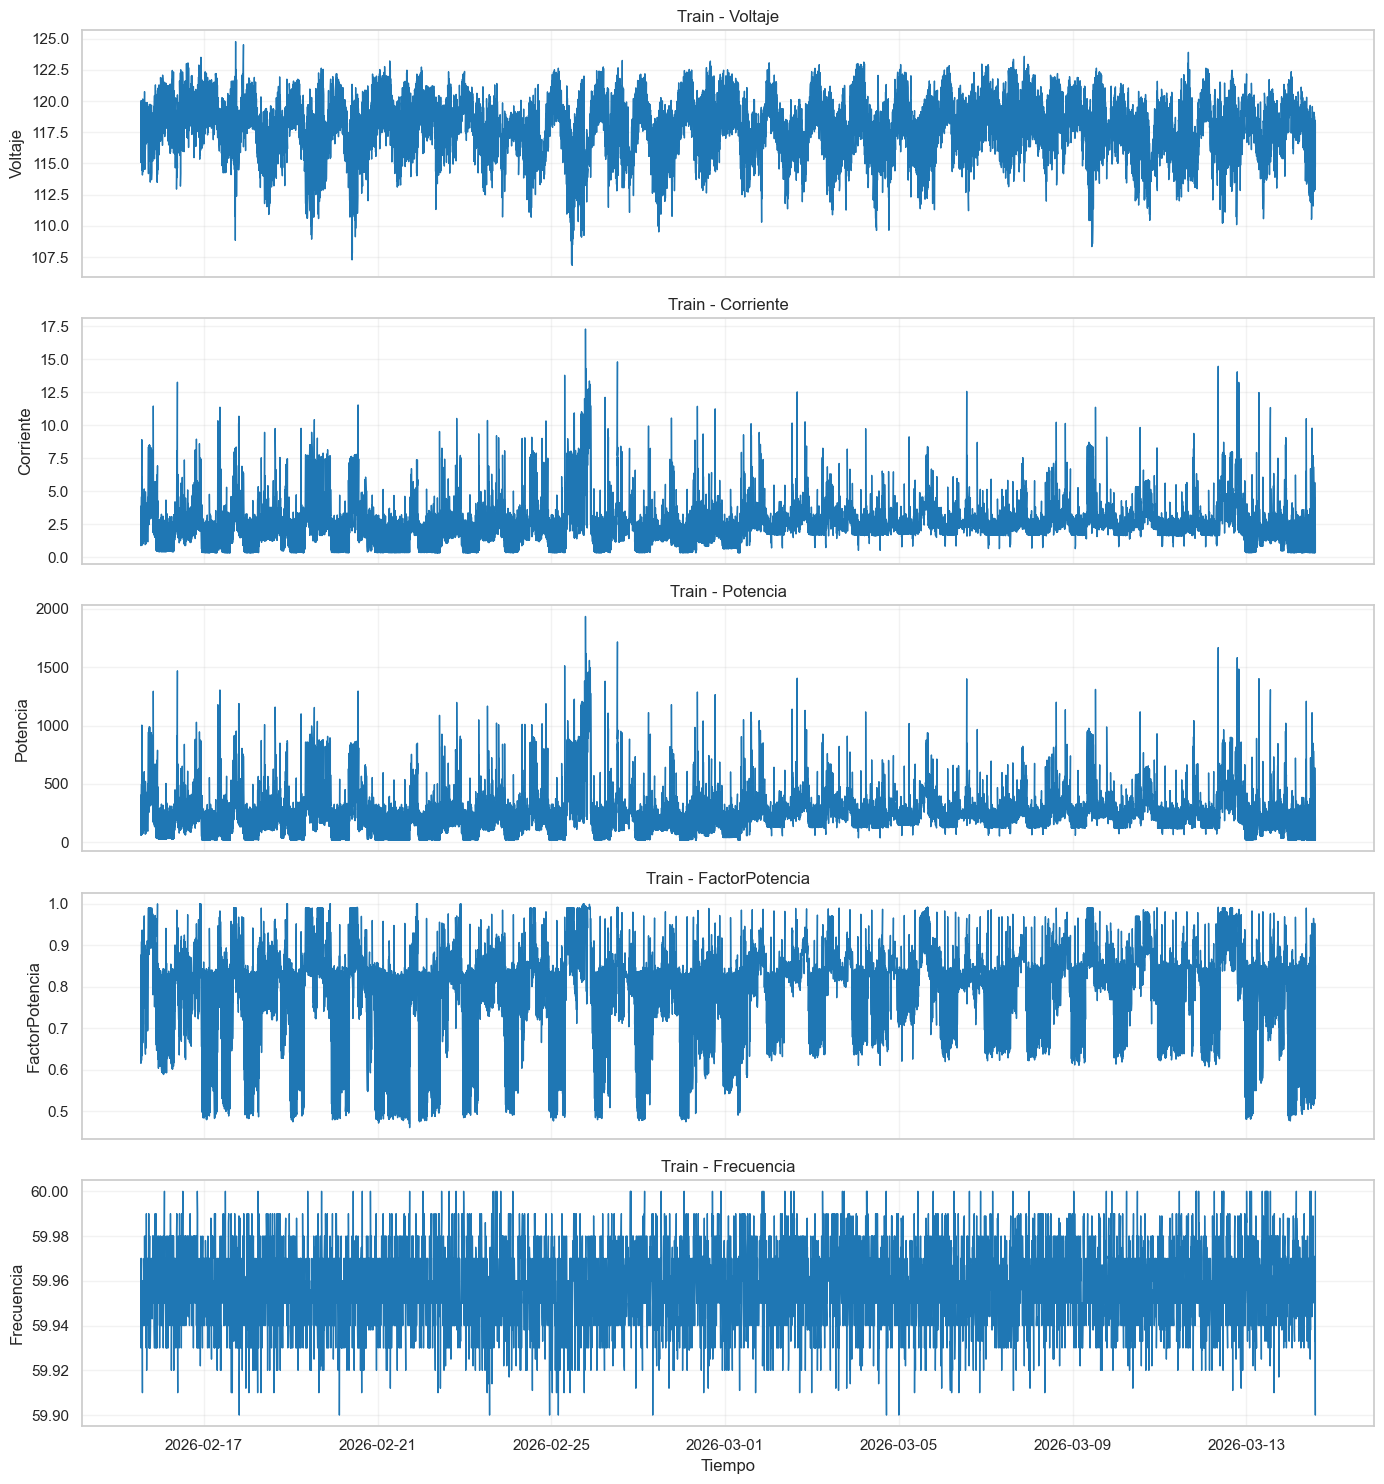

Gráficas de prueba:


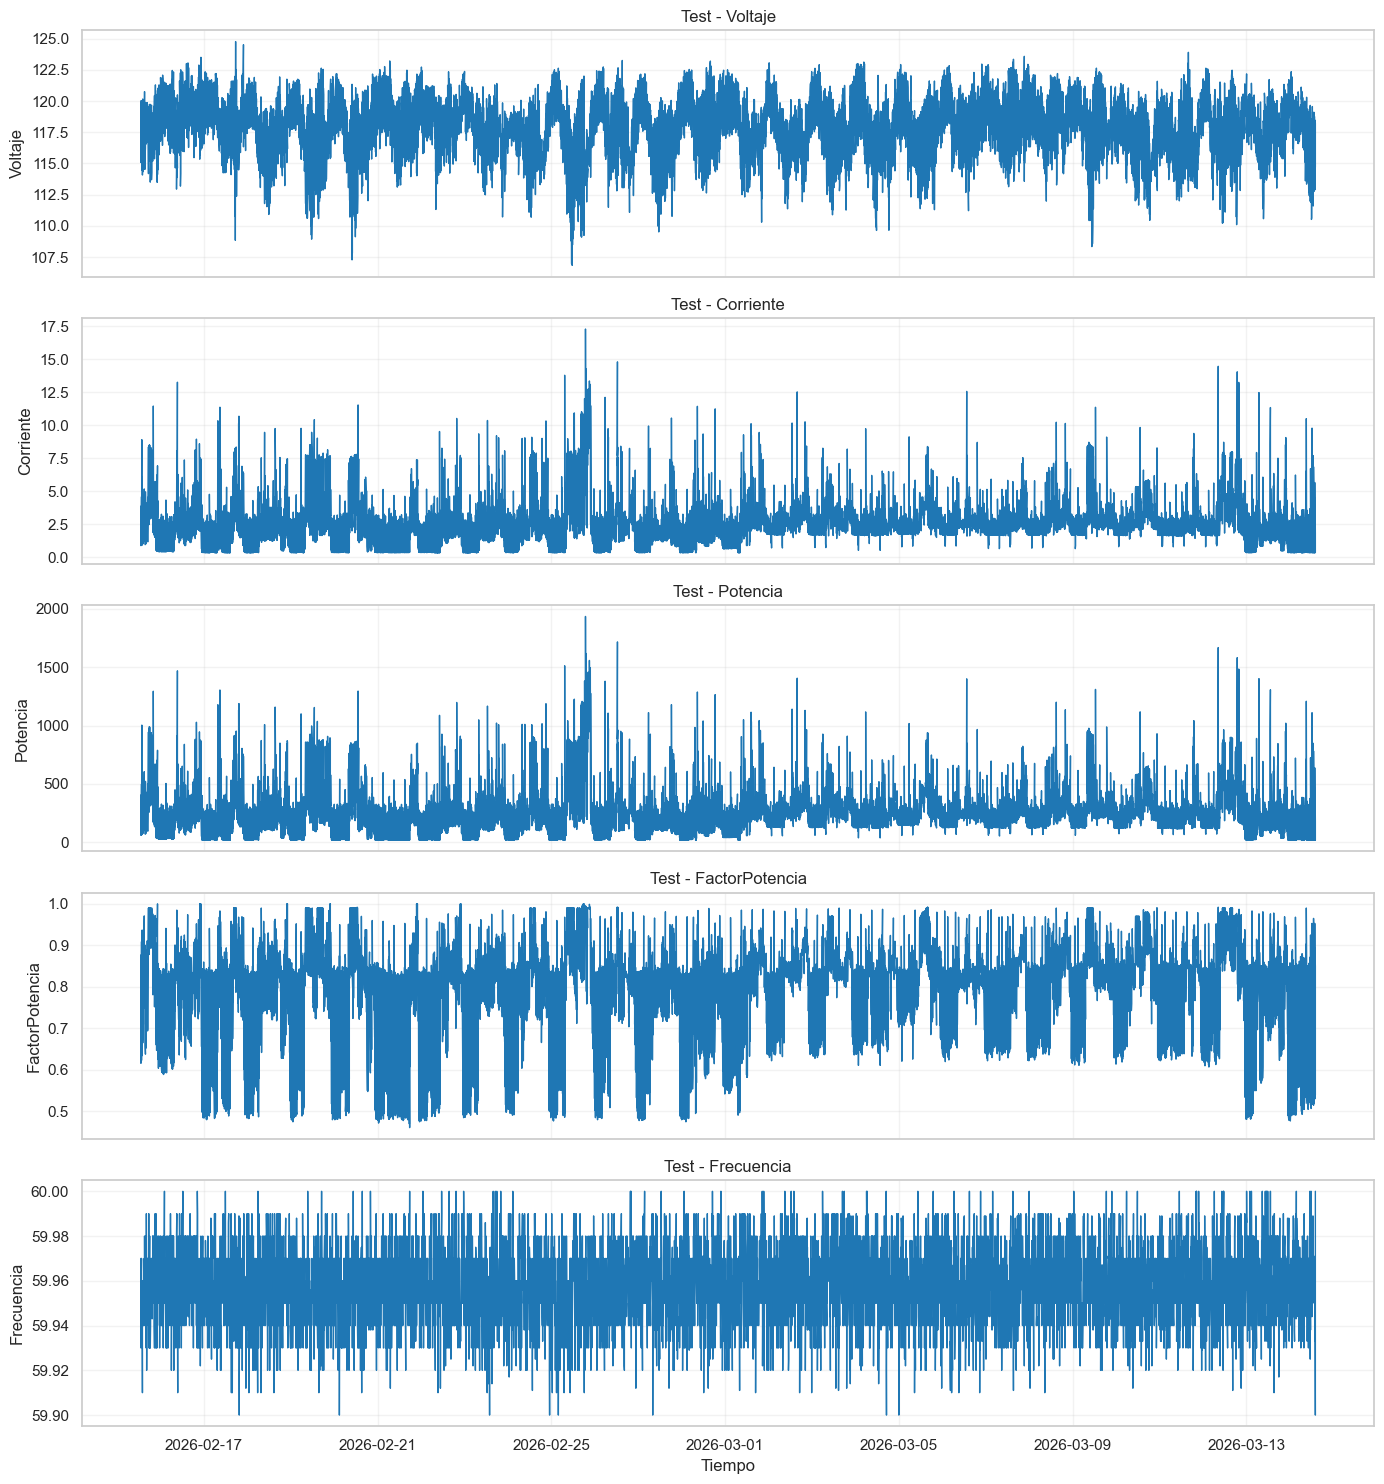

In [40]:
def graficar_series(df_serie, nombre_serie, columnas):
    candidatos_fecha = ["FechaMedicion", "fecha", "datetime", "timestamp", "ds"]
    col_fecha = next((c for c in candidatos_fecha if c in df_serie.columns), None)

    if col_fecha is not None:
        data = df_serie.copy()
        data[col_fecha] = pd.to_datetime(data[col_fecha], errors="coerce")
        data = data.dropna(subset=[col_fecha]).sort_values(col_fecha)
        eje_x = col_fecha
    else:
        data = df_serie.reset_index().rename(columns={"index": "idx"})
        eje_x = "idx"

    columnas_validas = [c for c in columnas if c in data.columns]
    if not columnas_validas:
        print(f"No hay columnas de columnas_analisis disponibles en {nombre_serie}.")
        return

    fig, axes = plt.subplots(
        nrows=len(columnas_validas),
        ncols=1,
        figsize=(14, 3.0 * len(columnas_validas)),
        sharex=True
    )

    if len(columnas_validas) == 1:
        axes = [axes]

    for ax, col in zip(axes, columnas_validas):
        ax.plot(data[eje_x], data[col], linewidth=1.0, color="#1f77b4")
        ax.set_title(f"{nombre_serie} - {col}")
        ax.set_ylabel(col)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()


columnas_graficar = ["Voltaje", "Corriente", "Potencia", "FactorPotencia", "Frecuencia"]

print("Gráficas de entrenamiento:")
graficar_series(df_train, "Train", columnas_graficar)
print("Gráficas de prueba:")
graficar_series(df_test, "Test", columnas_graficar)

Distribución de las variables

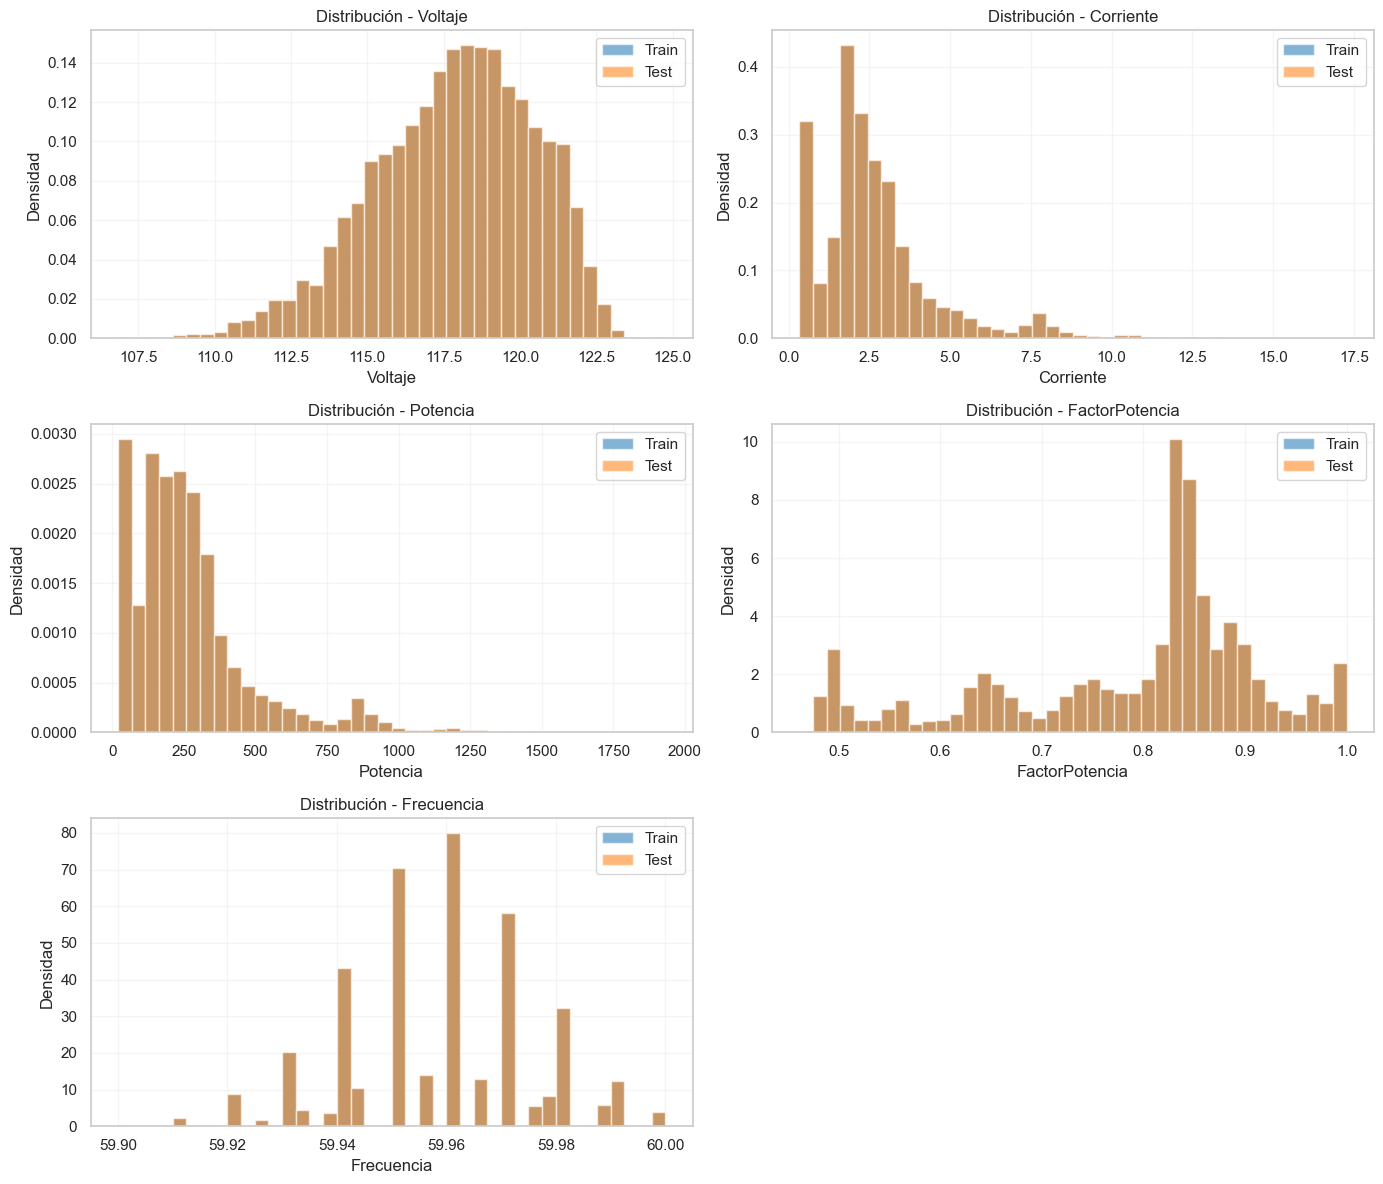

In [41]:
def graficar_distribucion_variables(df_train, df_test, columnas, bins=40):
    columnas_validas = [c for c in columnas if c in df_train.columns and c in df_test.columns]
    if not columnas_validas:
        print("No hay columnas válidas para graficar en train y test.")
        return

    n = len(columnas_validas)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(columnas_validas):
        ax = axes[i]
        train_vals = df_train[col].dropna()
        test_vals = df_test[col].dropna()

        ax.hist(train_vals, bins=bins, alpha=0.55, density=True, label="Train", color="#1f77b4")
        ax.hist(test_vals, bins=bins, alpha=0.55, density=True, label="Test", color="#ff7f0e")
        ax.set_title(f"Distribución - {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Densidad")
        ax.grid(alpha=0.2)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


graficar_distribucion_variables(df_train, df_test, columnas_graficar)

Descomposición de la serie

Descomposición de Train


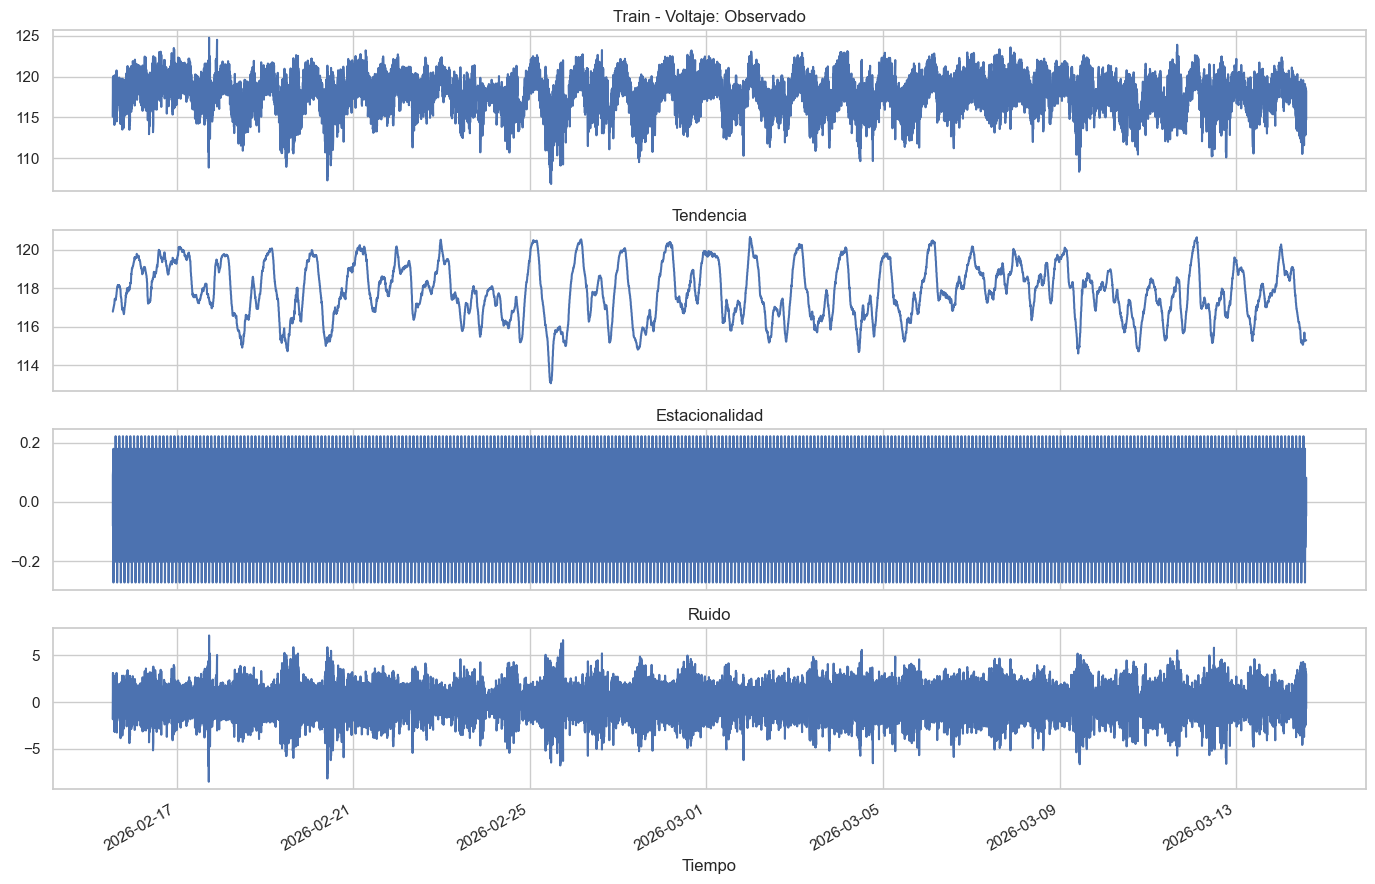

Descomposición completada: Train - Voltaje (periodo=24)


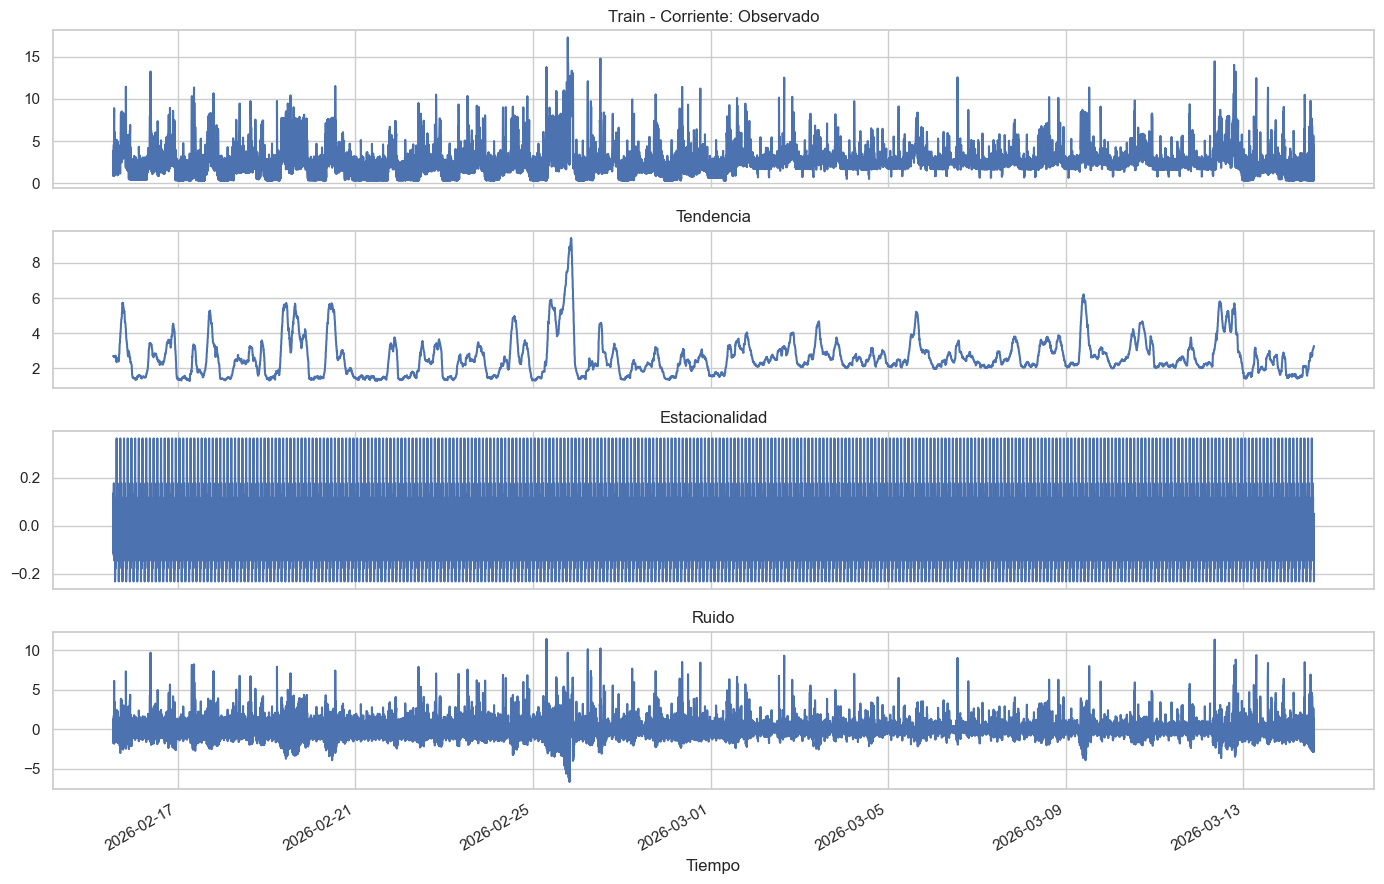

Descomposición completada: Train - Corriente (periodo=24)


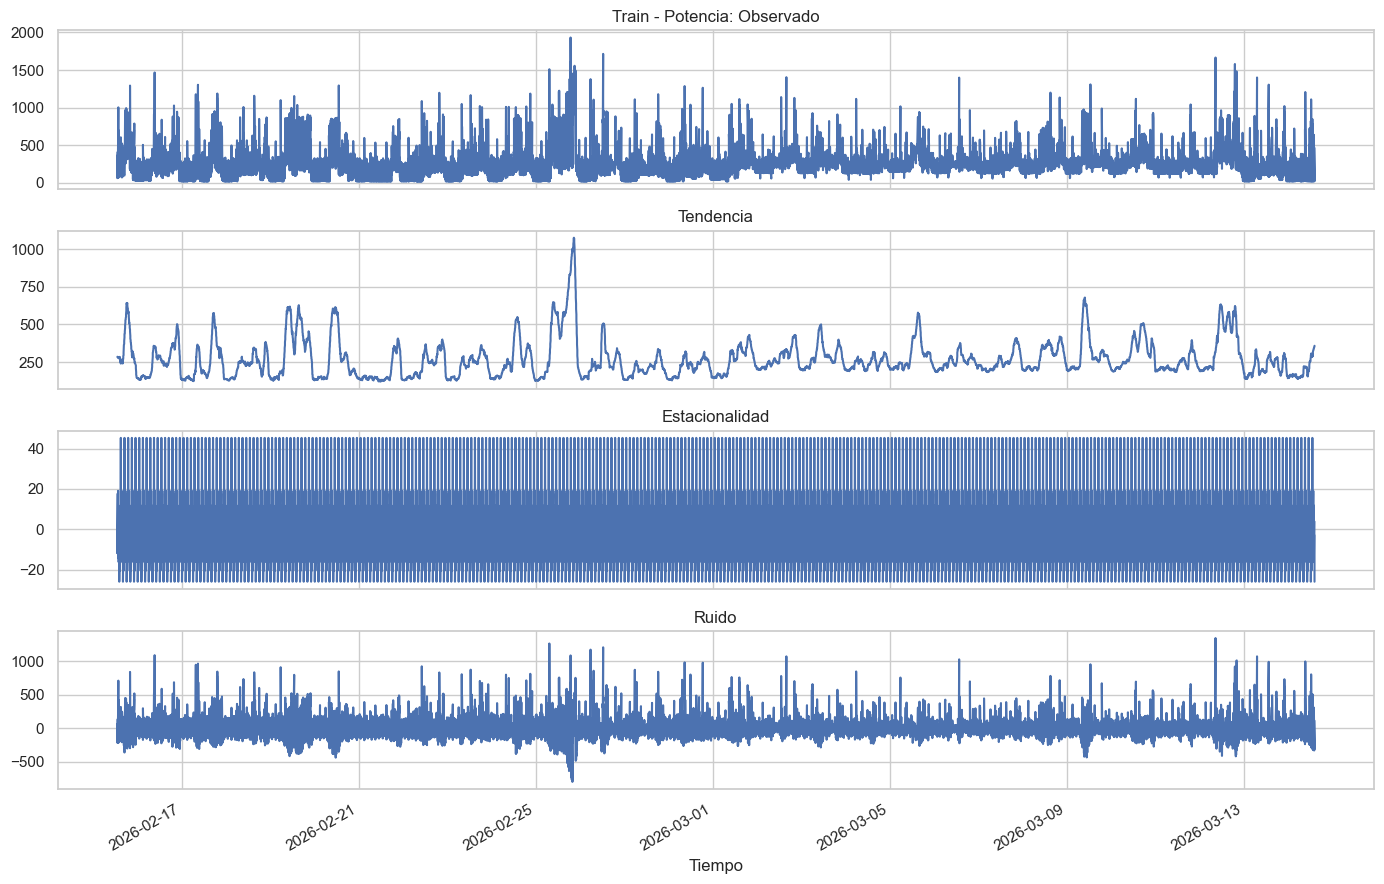

Descomposición completada: Train - Potencia (periodo=24)


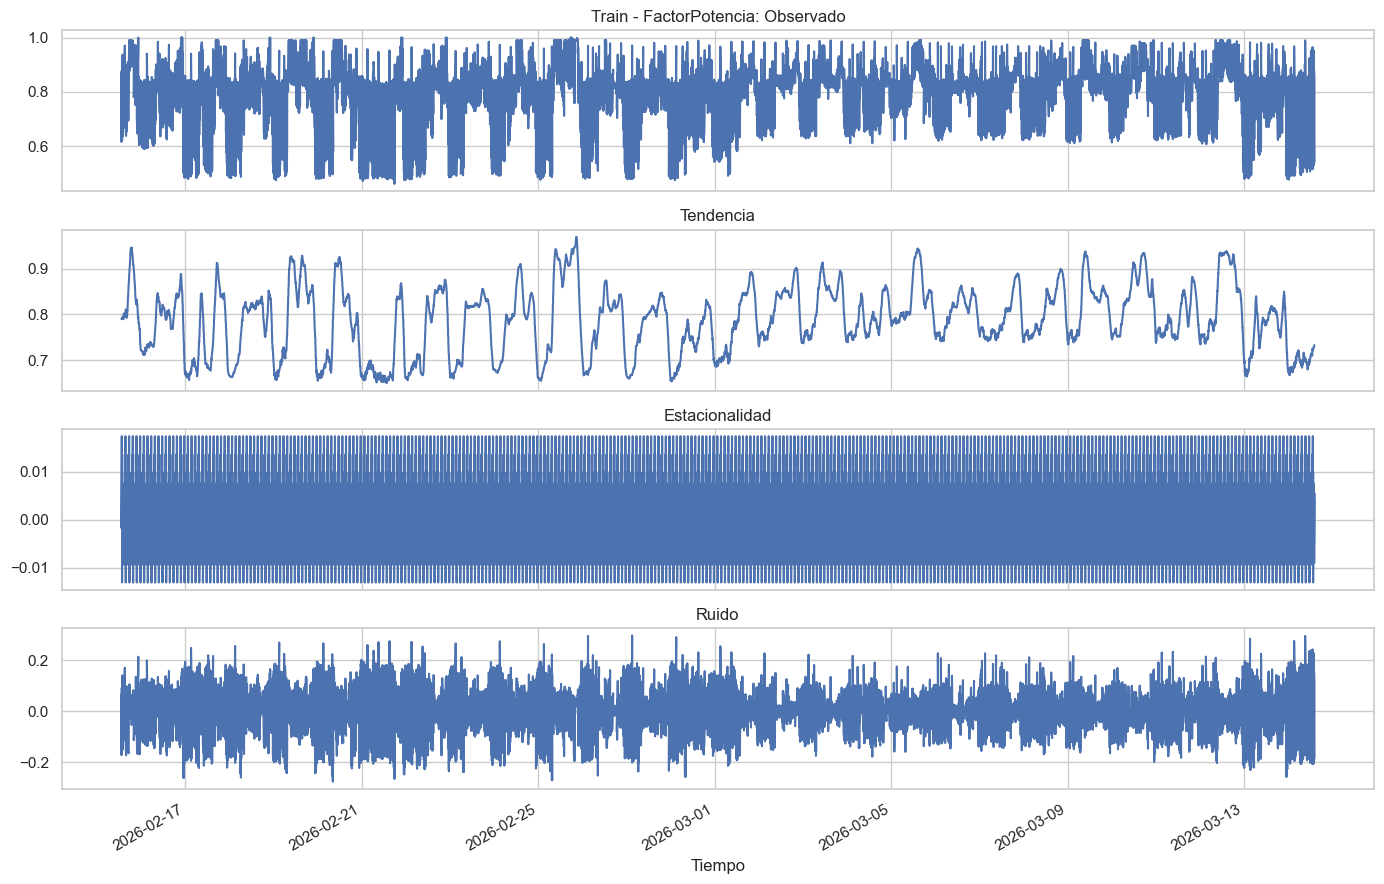

Descomposición completada: Train - FactorPotencia (periodo=24)


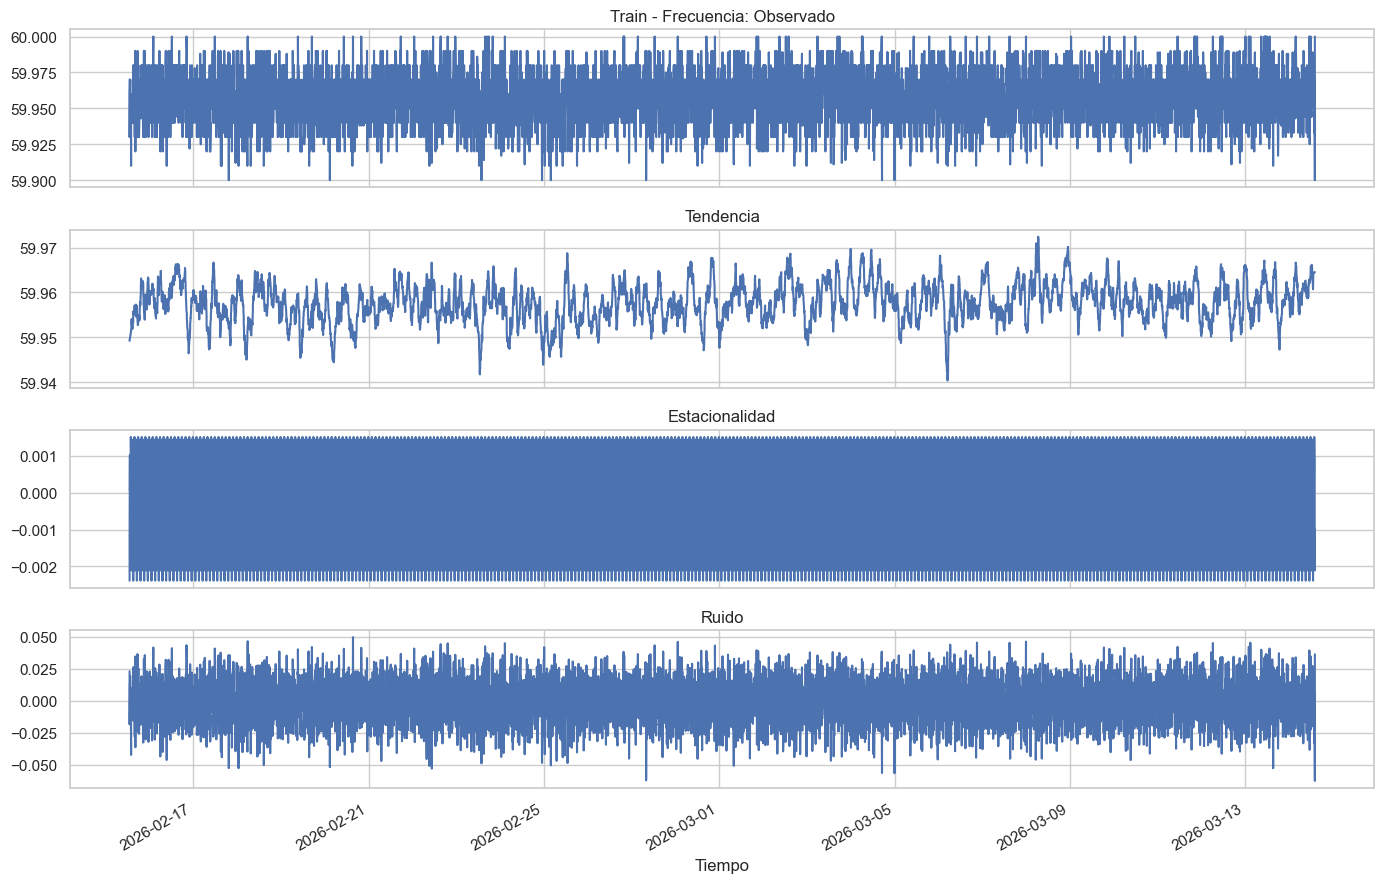

Descomposición completada: Train - Frecuencia (periodo=24)
Descomposición de Test


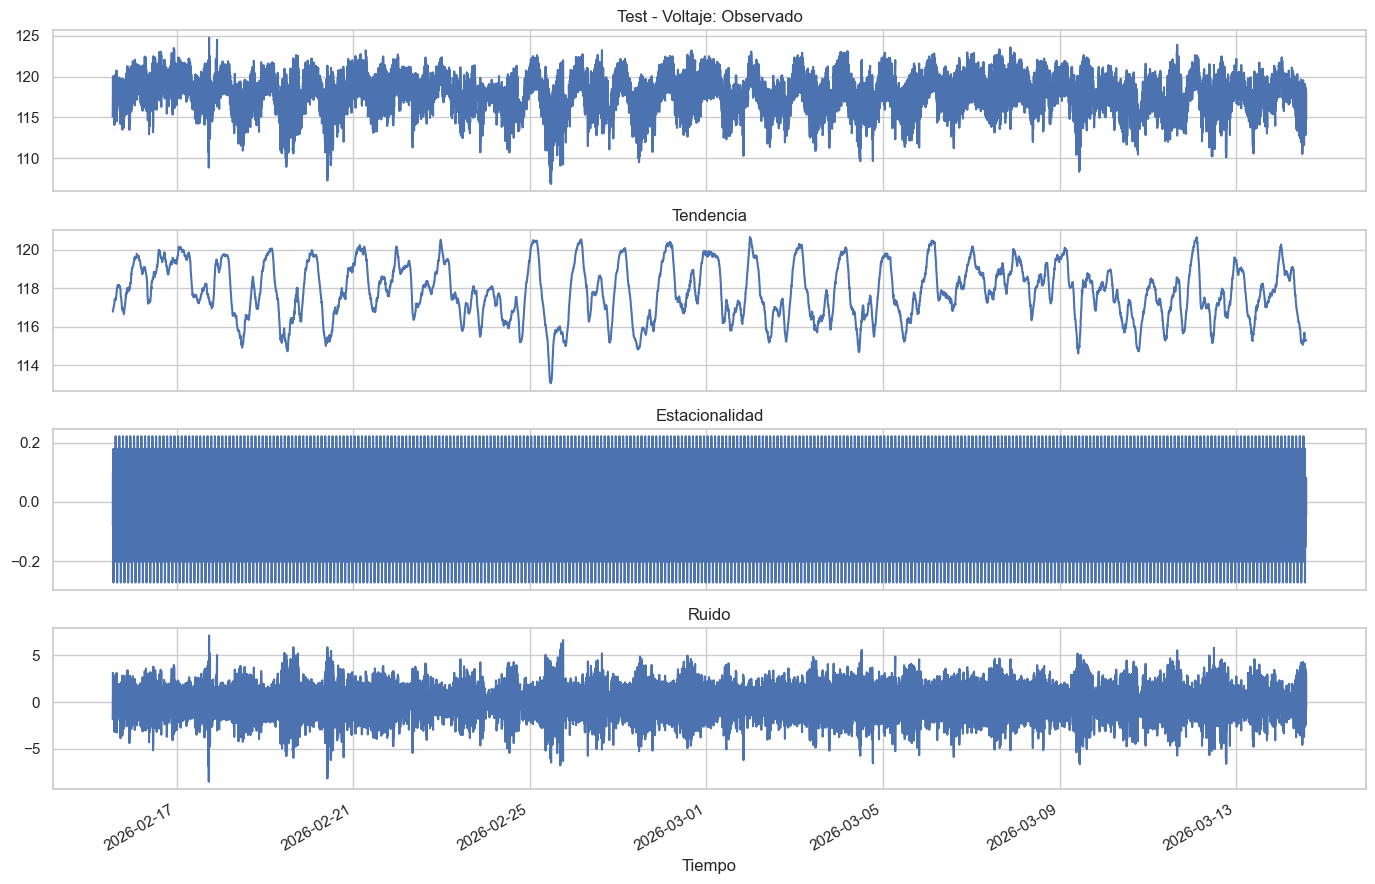

Descomposición completada: Test - Voltaje (periodo=24)


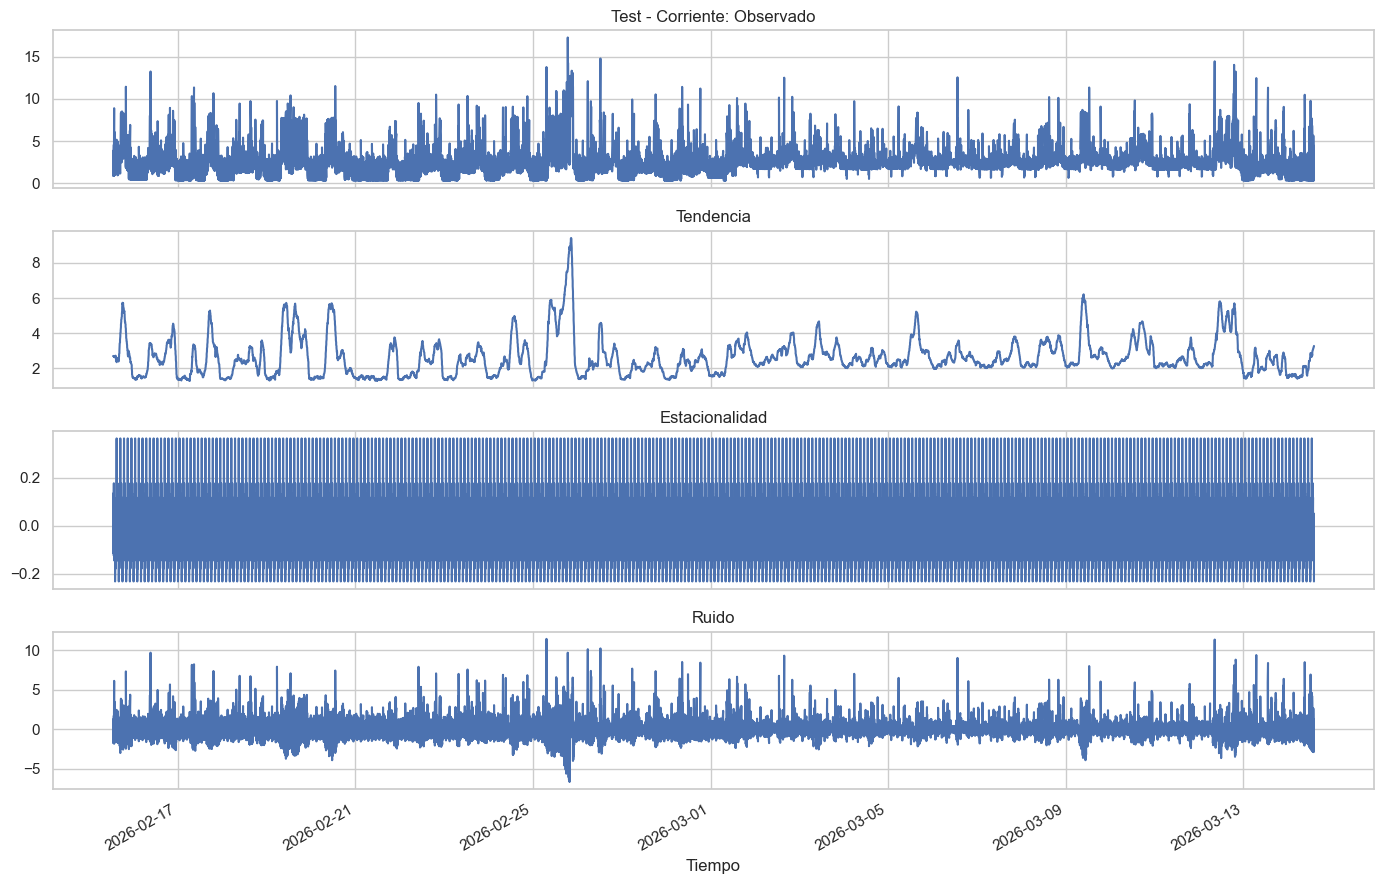

Descomposición completada: Test - Corriente (periodo=24)


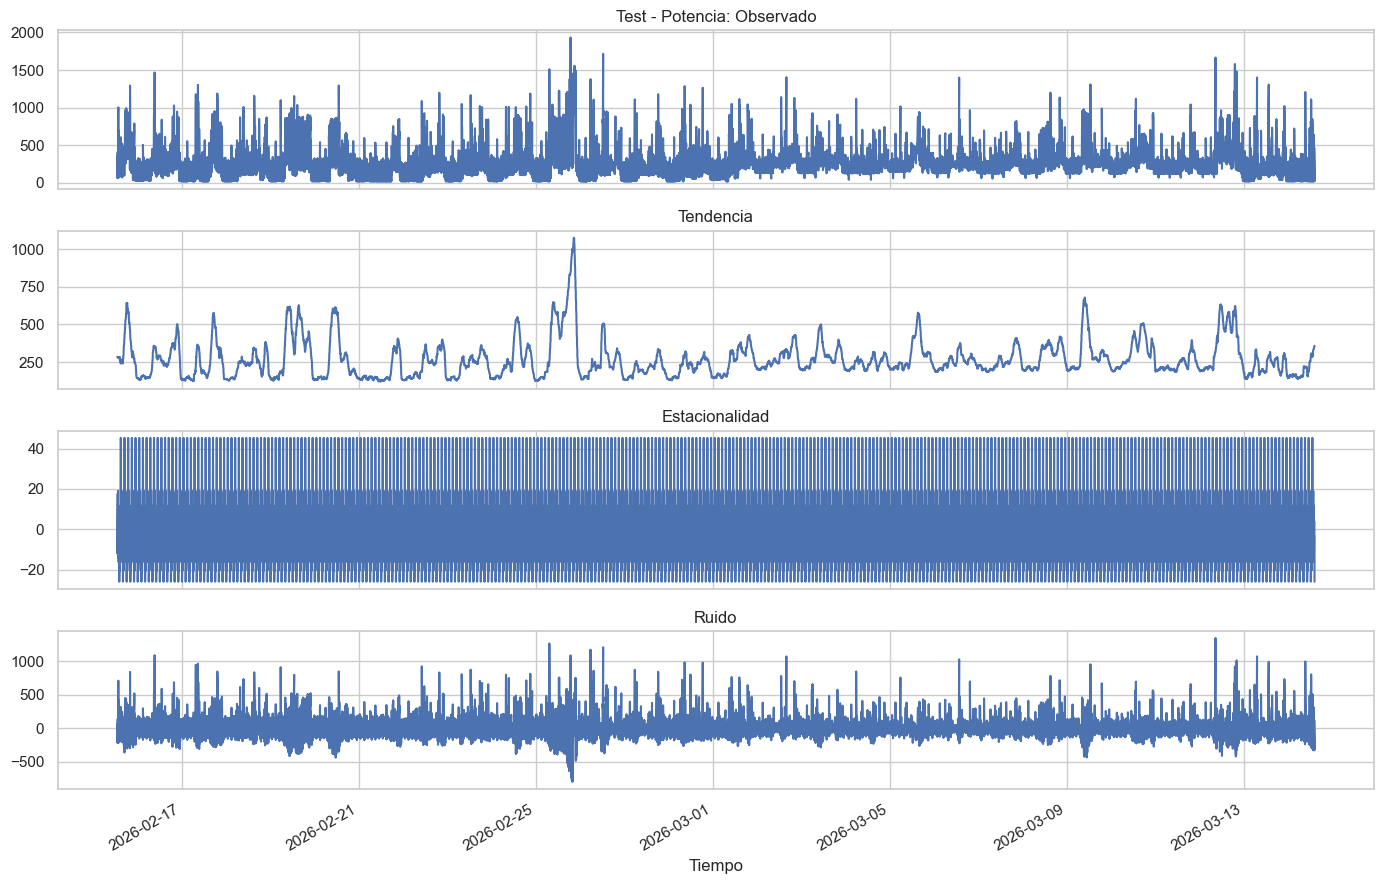

Descomposición completada: Test - Potencia (periodo=24)


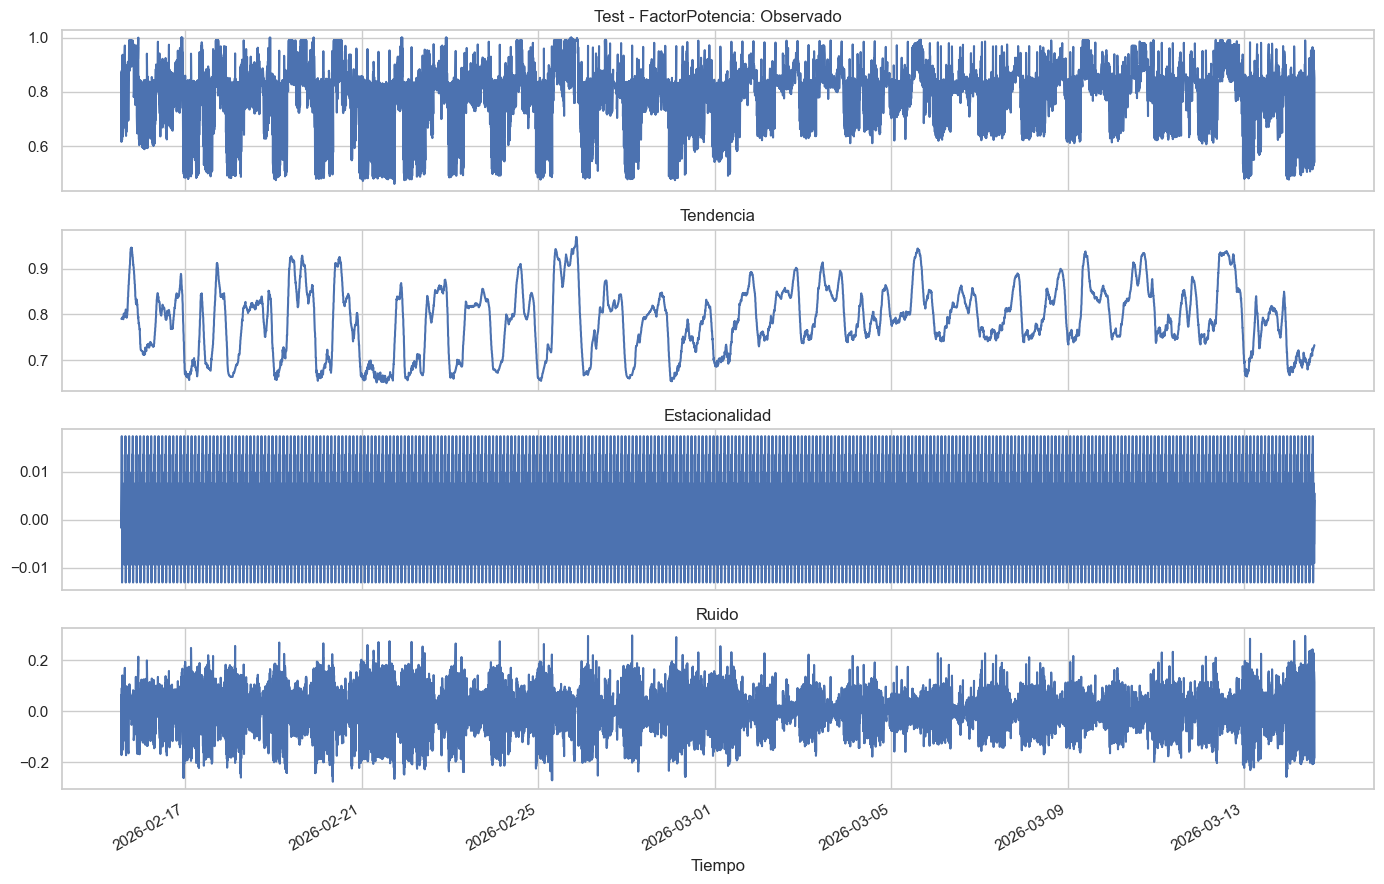

Descomposición completada: Test - FactorPotencia (periodo=24)


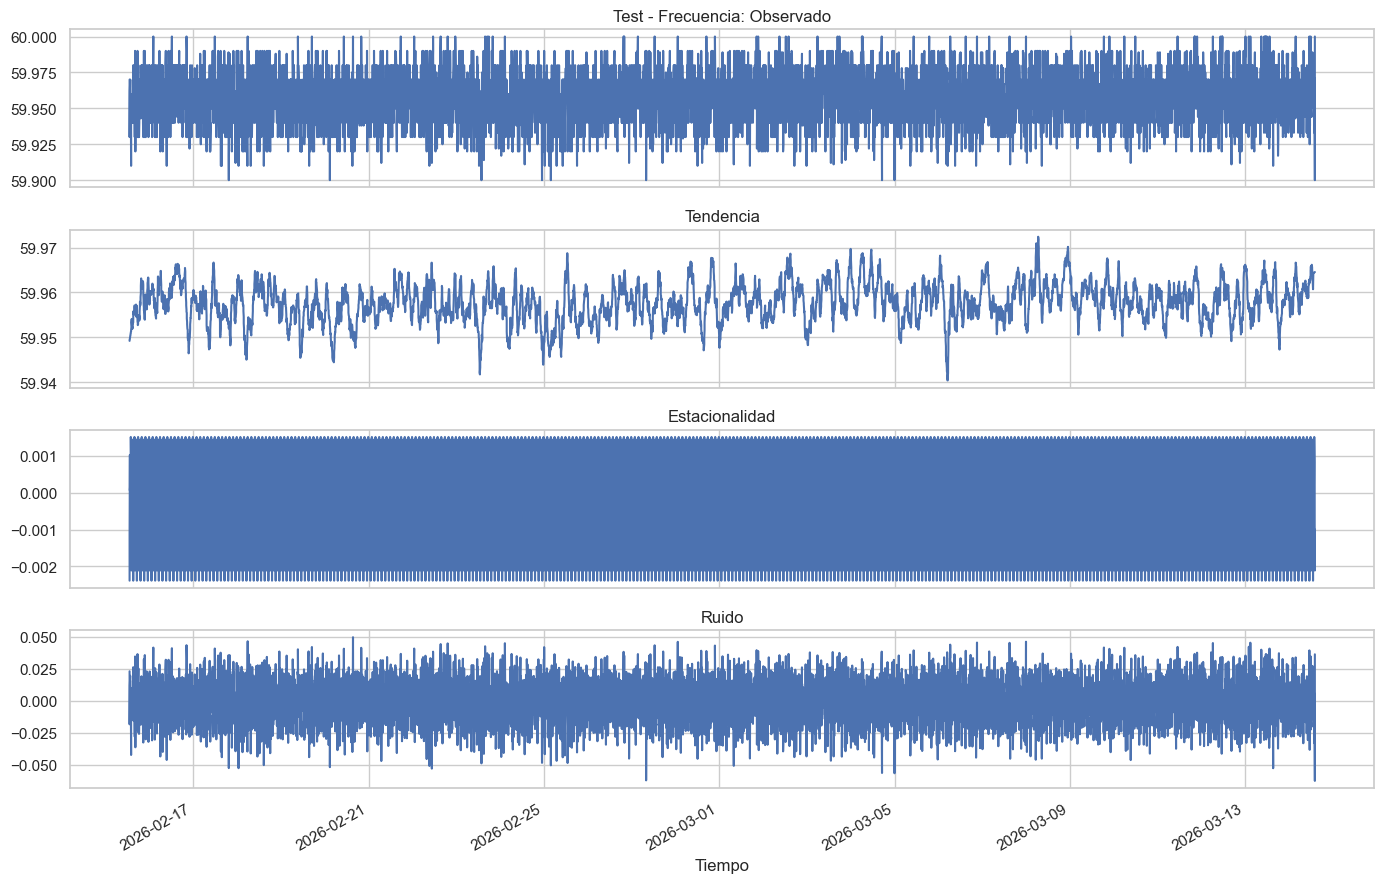

Descomposición completada: Test - Frecuencia (periodo=24)


In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

def _preparar_serie_para_descomposicion(df_serie, columna_objetivo):
    candidatos_fecha = ["FechaMedicion", "fecha", "datetime", "timestamp", "ds"]
    col_fecha = next((c for c in candidatos_fecha if c in df_serie.columns), None)

    if columna_objetivo not in df_serie.columns:
        return None

    data = df_serie[[columna_objetivo]].copy()
    data[columna_objetivo] = pd.to_numeric(data[columna_objetivo], errors="coerce")

    if col_fecha is not None:
        data[col_fecha] = pd.to_datetime(df_serie[col_fecha], errors="coerce")
        data = data.dropna(subset=[col_fecha, columna_objetivo]).sort_values(col_fecha)
        data = data.set_index(col_fecha)
    else:
        data = data.dropna(subset=[columna_objetivo]).reset_index(drop=True)
        data.index = pd.RangeIndex(start=0, stop=len(data), step=1)

    if data.empty:
        return None

    return data[columna_objetivo]

def _inferir_periodo(serie, periodo):
    if periodo is not None:
        return max(2, int(periodo))

    if isinstance(serie.index, pd.DatetimeIndex) and len(serie) > 2:
        delta_seg = serie.index.to_series().diff().dropna().dt.total_seconds().median()
        if pd.notna(delta_seg) and delta_seg > 0:
            return max(2, int(round(24 * 3600 / delta_seg)))

    return 24

def descomponer_series(df_serie, nombre_serie, columnas, modelo="additive", periodo=None):
    columnas_validas = [c for c in columnas if c in df_serie.columns]
    resultados = {}

    for col in columnas_validas:
        serie = _preparar_serie_para_descomposicion(df_serie, col)
        if serie is None or len(serie) < 2:
            print(f"{nombre_serie} - {col}: sin datos suficientes para descomponer.")
            continue

        periodo_col = _inferir_periodo(serie, periodo)
        max_periodo = max(2, len(serie) // 2)
        periodo_col = min(periodo_col, max_periodo)

        if len(serie) < 2 * periodo_col:
            print(f"{nombre_serie} - {col}: se requieren al menos {2 * periodo_col} puntos (actual: {len(serie)}).")
            continue

        resultado = seasonal_decompose(
            serie,
            model=modelo,
            period=periodo_col,
            extrapolate_trend="freq"
        )

        componentes = pd.DataFrame({
            "observado": resultado.observed,
            "tendencia": resultado.trend,
            "estacionalidad": resultado.seasonal,
            "ruido": resultado.resid,
        })
        resultados[col] = componentes

        fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
        componentes["observado"].plot(ax=axes[0], title=f"{nombre_serie} - {col}: Observado")
        componentes["tendencia"].plot(ax=axes[1], title="Tendencia")
        componentes["estacionalidad"].plot(ax=axes[2], title="Estacionalidad")
        componentes["ruido"].plot(ax=axes[3], title="Ruido")
        axes[3].set_xlabel("Tiempo")
        plt.tight_layout()
        plt.show()

        print(f"Descomposición completada: {nombre_serie} - {col} (periodo={periodo_col})")

    return resultados


print("Descomposición de Train")
componentes_train = descomponer_series(df_train, "Train", columnas_graficar)

print("Descomposición de Test")
componentes_test = descomponer_series(df_test, "Test", columnas_graficar)

Correlación entre variables

Matriz de correlación (pearson) - Train


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.094,-0.077,0.102,-0.014
Corriente,-0.094,1.000,0.997,0.753,0.006
Potencia,-0.077,0.997,1.000,0.755,0.005
FactorPotencia,0.102,0.753,0.755,1.000,0.011
Frecuencia,-0.014,0.006,0.005,0.011,1.000


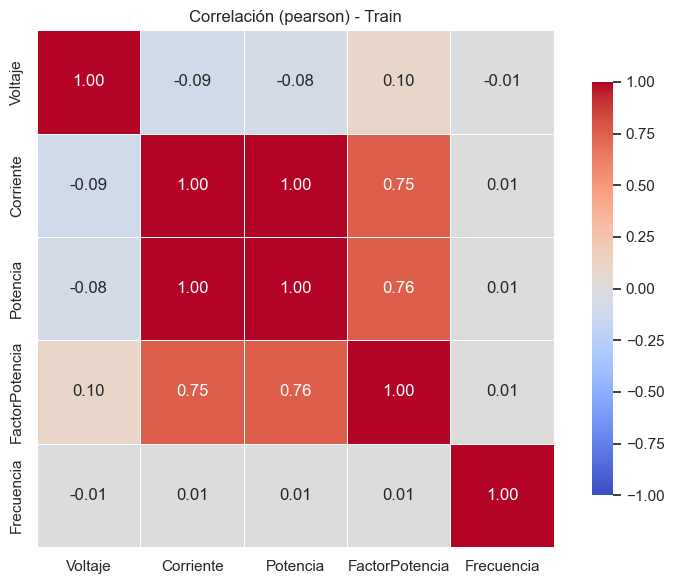

Matriz de correlación (pearson) - Test


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.094,-0.077,0.102,-0.014
Corriente,-0.094,1.000,0.997,0.753,0.006
Potencia,-0.077,0.997,1.000,0.755,0.005
FactorPotencia,0.102,0.753,0.755,1.000,0.011
Frecuencia,-0.014,0.006,0.005,0.011,1.000


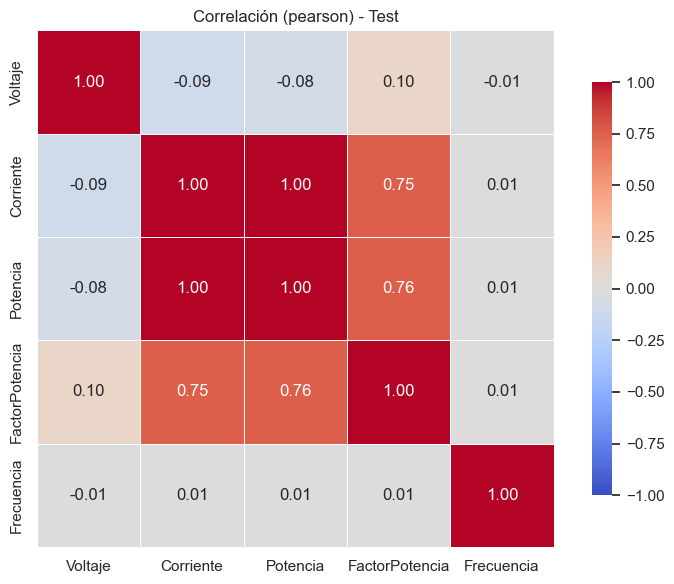

In [43]:
def calcular_y_graficar_correlacion(df_serie, nombre_serie, columnas, metodo="pearson"):
    columnas_validas = [c for c in columnas if c in df_serie.columns]
    if len(columnas_validas) < 2:
        print(f"{nombre_serie}: se requieren al menos 2 columnas para correlación.")
        return None

    data = df_serie[columnas_validas].apply(pd.to_numeric, errors="coerce")
    matriz_corr = data.corr(method=metodo)

    print(f"Matriz de correlación ({metodo}) - {nombre_serie}")
    display(matriz_corr.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        matriz_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"Correlación ({metodo}) - {nombre_serie}")
    plt.tight_layout()
    plt.show()

    return matriz_corr


corr_train = calcular_y_graficar_correlacion(df_train, "Train", columnas_graficar)
corr_test = calcular_y_graficar_correlacion(df_test, "Test", columnas_graficar)